CLASSICAL CNN MODEL USING SDG OPTIMIZER WITH MOMENTUM=0.9

In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [ ]:
# %pip install tensorflow[and-cuda]

  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.2-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached wrapt-2.0.1-cp

In [5]:
%pip install numpy pandas scikit-learn seaborn matplotlib

  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.16.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.0-cp312-cp312-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.met

In [6]:
import time
import csv
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Optimizer
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.models import load_model
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

2025-12-10 18:10:05.293851: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: # allow memory growth
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU config error:", e)


In [8]:
# ==========================
# 1️⃣ Load and Preprocess Data
# ==========================
def load_dataset(directory):
    X, y = [], []
    classes = sorted(os.listdir(directory))
    for label in classes:
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            img = load_img(img_path, target_size=(64, 64))
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y), classes

In [12]:

train_dir = "/home/hassan/QML/Brain_Tumor_data/Training"
X, y, class_names = load_dataset(train_dir)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded, num_classes=len(class_names))

print(f"[INFO] Loaded {len(X)} images across {len(class_names)} classes: {class_names}")

[INFO] Loaded 5712 images across 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Hybrid optimizer combining Adam (adaptive) and SGD (momentum).

mix_factor = 0 → Pure SGD

mix_factor = 1 → Pure Adam


In [21]:



class AdamSGDHybrid(Optimizer):

    def __init__(self,
                 learning_rate=0.001,
                 beta1=0.9,
                 beta2=0.999,
                 epsilon=1e-7,
                 momentum=0.9,
                 mix_factor=0.5,  # 50% Adam + 50% SGD
                 name="AdamSGDHybrid",
                 **kwargs):
        
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self._learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.momentum = momentum
        self.mix_factor = mix_factor   # between 0 and 1

    @property
    def learning_rate(self):
        return self._learning_rate
    
    def build(self, var_list):
        """Create optimizer state variables"""
        self.m = [tf.Variable(tf.zeros_like(v), trainable=False) for v in var_list]
        self.v = [tf.Variable(tf.zeros_like(v), trainable=False) for v in var_list]
        self.sgd_mom = [tf.Variable(tf.zeros_like(v), trainable=False) for v in var_list]

    def update_step(self, grad, var, m, v, sgd_mom):
        lr = self.learning_rate

        # Adam moments
        m.assign(self.beta1 * m + (1 - self.beta1) * grad)
        v.assign(self.beta2 * v + (1 - self.beta2) * tf.square(grad))

        adam_update = m / (tf.sqrt(v) + self.epsilon)

        # SGD with momentum
        sgd_mom.assign(self.momentum * sgd_mom + grad)
        sgd_update = sgd_mom

        # Hybrid combination
        final_update = (self.mix_factor * adam_update) + ((1 - self.mix_factor) * sgd_update)

        # Apply update
        var.assign_sub(lr * final_update)

    def apply_gradients(self, grads_and_vars, **kwargs):
        grads, vars_list = zip(*grads_and_vars)
        
        if not hasattr(self, "m"):
            self.build(vars_list)

        for grad, var, m, v, sgd_mom in zip(grads, vars_list, self.m, self.v, self.sgd_mom):
            if grad is not None:
                self.update_step(grad, var, m, v, sgd_mom)

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "beta1": self.beta1,
            "beta2": self.beta2,
            "epsilon": self.epsilon,
            "momentum": self.momentum,
            "mix_factor": self.mix_factor
        }


In [22]:
hybrid_optimizer = AdamSGDHybrid(
    learning_rate=0.001,
    beta1=0.9,
    beta2=0.999,
    momentum=0.9,
    mix_factor=0.5   # 50% Adam + 50% SGD
)



In [23]:

# ==========================
# 2️⃣ Define CNN Model (with your updated architecture)
# ==========================
def build_cnn(input_shape=(64,64,3), num_classes=4):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Dense Layers
        Flatten(),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=hybrid_optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [24]:

# ==========================
# ⏱️ Custom Callback for Timing
# ==========================
class TimingCallback(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start_time
        self.epoch_times.append(epoch_time)
        print(f"⏱️ Time for Epoch {epoch + 1}: {epoch_time:.2f} seconds")

In [25]:

# ==========================
# 3️⃣ K-Fold Cross Validation with Timing
# ==========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
fold_accuracies = []
fold_times = []
epoch_time_records = []

os.makedirs("logs", exist_ok=True)

for train_index, val_index in kf.split(X):
    print(f"\n[INFO] Training Fold {fold_no}...")
    fold_start_time = time.time()

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y_cat[train_index], y_cat[val_index]

    model = build_cnn((64, 64, 3), len(class_names))

    timing_callback = TimingCallback()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=16,
        verbose=1,
        callbacks=[timing_callback]
    )

    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)

    print(f"🕒 Total Time for Fold {fold_no}: {fold_time:.2f} seconds")
    
    # Store epoch times + metrics
    for epoch, t in enumerate(timing_callback.epoch_times, start=1):
        epoch_time_records.append([
            fold_no,
            epoch,
            t,
            history.history['loss'][epoch-1],
            history.history['accuracy'][epoch-1],
            history.history['val_loss'][epoch-1],
            history.history['val_accuracy'][epoch-1]
        ])
        
    acc = np.max(history.history['val_accuracy'])
    fold_accuracies.append(acc)
    model.save(f"classical_cnn_SGD_fold{fold_no}.keras")

    print(f"[INFO] Fold {fold_no} Accuracy: {acc:.4f}")
    fold_no += 1


[INFO] Training Fold 1...


/home/hassan/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


2025-12-10 18:25:25.221902: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 224575488 exceeds 10% of free system memory.
2025-12-10 18:25:25.593468: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 224575488 exceeds 10% of free system memory.


286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6789 - loss: 0.8633⏱️ Time for Epoch 1: 18.64 seconds
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.7431 - loss: 0.7033 - val_accuracy: 0.6640 - val_loss: 0.8748
Epoch 2/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7973 - loss: 0.5531⏱️ Time for Epoch 2: 4.08 seconds
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7827 - loss: 0.5848 - val_accuracy: 0.8495 - val_loss: 0.4344
Epoch 3/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8182 - loss: 0.4944⏱️ Time for Epoch 3: 4.11 seconds
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8247 - loss: 0.4902 - val_accuracy: 0.8478 - val_loss: 0.3691
Epoch 4/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8420 - loss: 0.4340⏱️ Time for Epoch 4: 4.10 seconds
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8475 - loss: 0.4192 - val_accuracy: 0.8845 - val_loss: 0.3145
Epoch 5/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - ac

2025-12-10 18:27:45.040343: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 224575488 exceeds 10% of free system memory.


286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6663 - loss: 0.8920⏱️ Time for Epoch 1: 17.56 seconds
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.7406 - loss: 0.6975 - val_accuracy: 0.4663 - val_loss: 1.3224
Epoch 2/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8189 - loss: 0.5109⏱️ Time for Epoch 2: 4.11 seconds
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8258 - loss: 0.4830 - val_accuracy: 0.6667 - val_loss: 0.9170
Epoch 3/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8404 - loss: 0.4479⏱️ Time for Epoch 3: 4.06 seconds
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8496 - loss: 0.4196 - val_accuracy: 0.8758 - val_loss: 0.3425
Epoch 4/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8765 - loss: 0.3672⏱️ Time for Epoch 4: 4.06 seconds
286/286 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8717 - loss: 0.3629 - val_accuracy: 0.8504 - val_loss: 0.3636
Epoch 5/30
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - ac

In [26]:
mean_acc = np.mean(fold_accuracies)
mean_time = np.mean(fold_times)

print(f"\n✅ Mean K-Fold Validation Accuracy: {mean_acc:.4f}")
print(f"⏰ Average Time per Fold: {mean_time:.2f} seconds")


✅ Mean K-Fold Validation Accuracy: 0.9634
⏰ Average Time per Fold: 139.26 seconds


In [27]:
import pandas as pd

df = pd.DataFrame(epoch_time_records, 
                  columns=["Fold", "Epoch", "Time", 
                           "Train_Loss", "Train_Acc", 
                           "Val_Loss", "Val_Acc"])
df.to_csv("logs/epoch_metrics.csv", index=False)


In [28]:
# ==========================
# 📊 Save Timing Data & Visualize
# ==========================
csv_path = "logs/epoch_training_times.csv"
with open(csv_path, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Fold", "Epoch", "Time (seconds)"])
    writer.writerows(epoch_time_records)

print(f"[INFO] Training time data saved at: {csv_path}")

[INFO] Training time data saved at: logs/epoch_training_times.csv


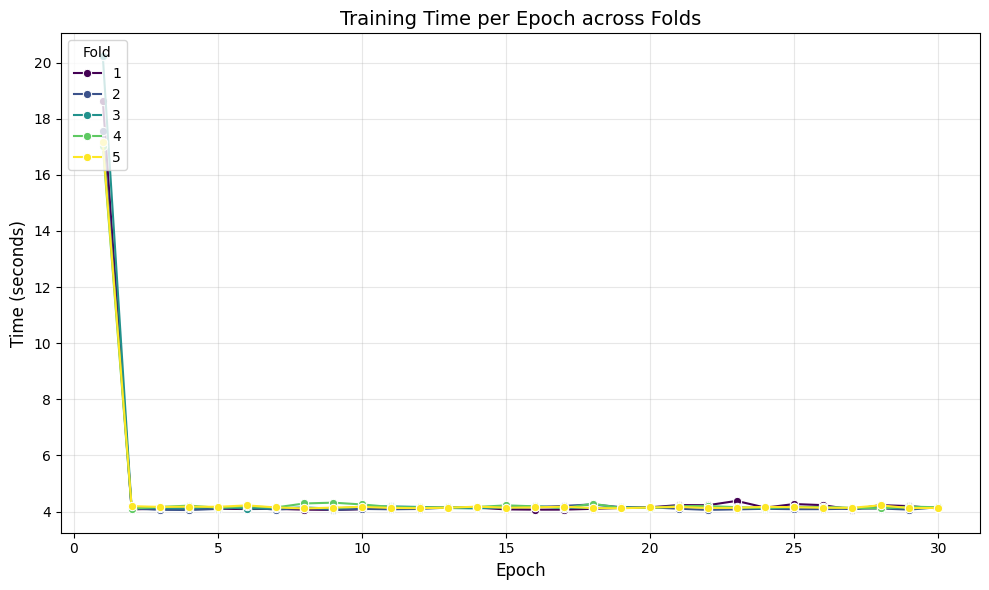

In [29]:
# Create visualization of epoch times
epoch_time_records = np.array(epoch_time_records)
folds = epoch_time_records[:, 0].astype(int)
epochs = epoch_time_records[:, 1].astype(int)
times = epoch_time_records[:, 2].astype(float)

plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs, y=times, hue=folds, marker="o", palette="viridis")
plt.title("Training Time per Epoch across Folds", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Time (seconds)", fontsize=12)
plt.legend(title="Fold", loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("logs/epoch_time_plot.png")
plt.show()

In [30]:
# ==========================
# ✅ Final Stats
# ==========================
mean_acc = np.mean(fold_accuracies)
mean_time = np.mean(fold_times)

print(f"\n✅ Mean K-Fold Validation Accuracy: {mean_acc:.4f}")
print(f"⏰ Average Time per Fold: {mean_time:.2f} seconds")


✅ Mean K-Fold Validation Accuracy: 0.9634
⏰ Average Time per Fold: 139.26 seconds


In [31]:
model.save("classical_cnn_SGD_complete.keras")
print("[INFO] Final model saved successfully!")

[INFO] Final model saved successfully!


In [38]:
from keras.saving import register_keras_serializable
from keras.optimizers import Optimizer
import tensorflow as tf

@register_keras_serializable(package="Custom", name="AdamSGDHybrid")
class AdamSGDHybrid(Optimizer):

    def __init__(self,
                 learning_rate=0.001,
                 beta1=0.9,
                 beta2=0.999,
                 epsilon=1e-7,
                 momentum=0.9,
                 mix_factor=0.5,  # 50% Adam + 50% SGD
                 name="AdamSGDHybrid",
                 **kwargs):
        
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self._learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.momentum = momentum
        self.mix_factor = mix_factor   # between 0 and 1

    @property
    def learning_rate(self):
        return self._learning_rate
    
    def build(self, var_list):
        """Create optimizer state variables"""
        self.m = [tf.Variable(tf.zeros_like(v), trainable=False) for v in var_list]
        self.v = [tf.Variable(tf.zeros_like(v), trainable=False) for v in var_list]
        self.sgd_mom = [tf.Variable(tf.zeros_like(v), trainable=False) for v in var_list]

    def update_step(self, grad, var, m, v, sgd_mom):
        lr = self.learning_rate

        # Adam moments
        m.assign(self.beta1 * m + (1 - self.beta1) * grad)
        v.assign(self.beta2 * v + (1 - self.beta2) * tf.square(grad))

        adam_update = m / (tf.sqrt(v) + self.epsilon)

        # SGD with momentum
        sgd_mom.assign(self.momentum * sgd_mom + grad)
        sgd_update = sgd_mom

        # Hybrid combination
        final_update = (self.mix_factor * adam_update) + ((1 - self.mix_factor) * sgd_update)

        # Apply update
        var.assign_sub(lr * final_update)

    def apply_gradients(self, grads_and_vars, **kwargs):
        grads, vars_list = zip(*grads_and_vars)
        
        if not hasattr(self, "m"):
            self.build(vars_list)

        for grad, var, m, v, sgd_mom in zip(grads, vars_list, self.m, self.v, self.sgd_mom):
            if grad is not None:
                self.update_step(grad, var, m, v, sgd_mom)

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "beta1": self.beta1,
            "beta2": self.beta2,
            "epsilon": self.epsilon,
            "momentum": self.momentum,
            "mix_factor": self.mix_factor
        }
hybrid_optimizer = AdamSGDHybrid(
    learning_rate=0.001,
    beta1=0.9,
    beta2=0.999,
    momentum=0.9,
    mix_factor=0.5   # 50% Adam + 50% SGD
)




In [44]:

# ==========================
# 4️⃣ Evaluate and Visualize (using test set)
# ==========================
from keras.models import load_model

model = load_model(
    "/home/hassan/QML/HybridOptimizer/classical_cnn_AdamSGD_complete.keras",
    custom_objects={"AdamSGDHybrid": hybrid_optimizer}
)

TEST_DIR = "/home/hassan/QML/Brain_Tumor_data/Testing"
def load_test_dataset(directory, img_size=(64, 64)):
    X, y = [], []
    classes = sorted(os.listdir(directory))
    for label in classes:
        class_dir = os.path.join(directory, label)
        if not os.path.isdir(class_dir):
            continue
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            img = load_img(img_path, target_size=img_size)
            img = img_to_array(img) / 255.0
            X.append(img)
            y.append(label)
    return np.array(X), np.array(y)

X_test, y_test = load_test_dataset(TEST_DIR)
y_test_enc = encoder.transform(y_test)
y_test_cat = to_categorical(y_test_enc, num_classes=len(class_names))

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=1)
print(f"\n🎯 Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred_probs = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
print("\n📊 Classification Report:")
print(classification_report(y_test_enc, y_pred))
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test_enc, y_pred))


40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8707 - loss: 0.5090

2025-12-10 18:48:00.210719: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_275', 8 bytes spill stores, 8 bytes spill loads



41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9092 - loss: 0.3218

🎯 Test Accuracy: 0.9092
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90       300
           1       0.74      0.96      0.84       306
           2       0.99      0.86      0.92       405
           3       0.96      1.00      0.98       300

    accuracy                           0.91      1311
   macro avg       0.92      0.91      0.91      1311
weighted avg       0.93      0.91      0.91      1311


📊 Confusion Matrix:
[[248  45   0   7]
 [  2 295   2   7]
 [  0  55 350   0]
 [  0   1   0 299]]


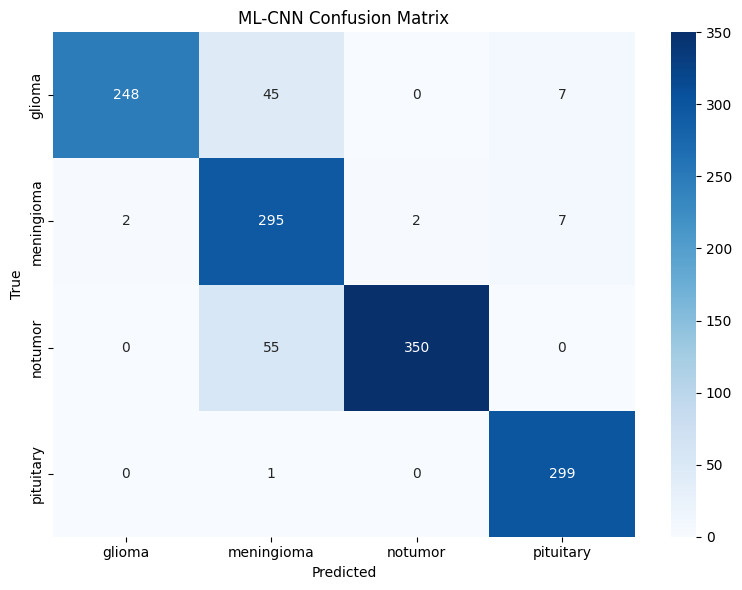

In [45]:
# Confusion Matrix
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ML-CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('mlcnn_confusion_matrix.png', dpi=300)
plt.show()

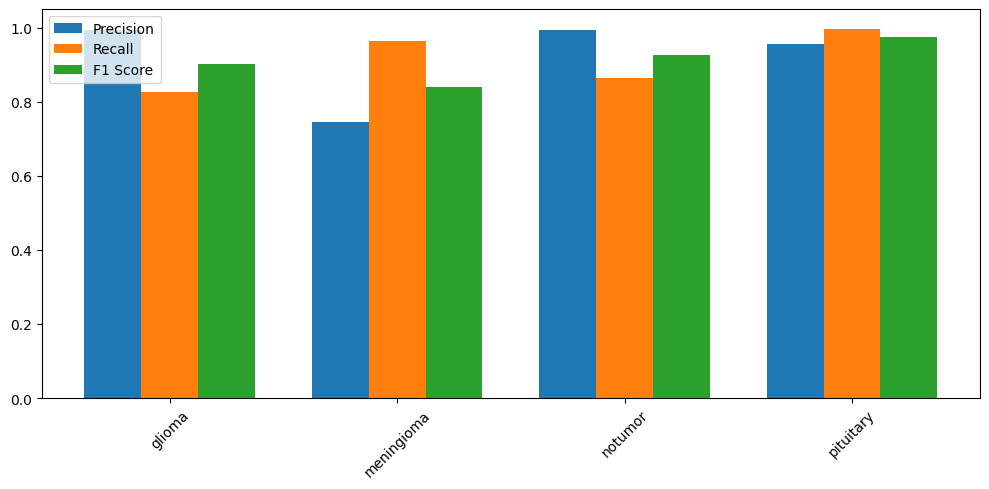

In [46]:
# Precision, Recall, F1
precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred, average=None)
x = np.arange(len(class_names))
width = 0.25
plt.figure(figsize=(10,5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')
plt.xticks(x, class_names, rotation=45)
plt.ylim([0, 1.05])
plt.legend()
plt.tight_layout()
plt.savefig('mlcnn_performance_metrics.png', dpi=300)
plt.show()

In [47]:
# ==========================
# 5️⃣ Save Results
# ==========================
from datetime import datetime
import json


results = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'model_config': {'img_size': (64, 64, 3), 'num_classes': len(class_names)},
    'kfold_results': {'fold_scores': [float(s) for s in fold_accuracies],
                      'mean_accuracy': float(np.mean(fold_accuracies)),
                      'std_accuracy': float(np.std(fold_accuracies))},
    'test_accuracy': float(test_acc)
}

with open('mlcnn_results.json', 'w') as f:
    json.dump(results, f, indent=4)
print("💾 Saved: mlcnn_results.json")


💾 Saved: mlcnn_results.json


In [48]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 813,668 (3.10 MB)

 Trainable params: 812,644 (3.10 MB)

 Non-trainable params: 1,024 (4.00 KB)

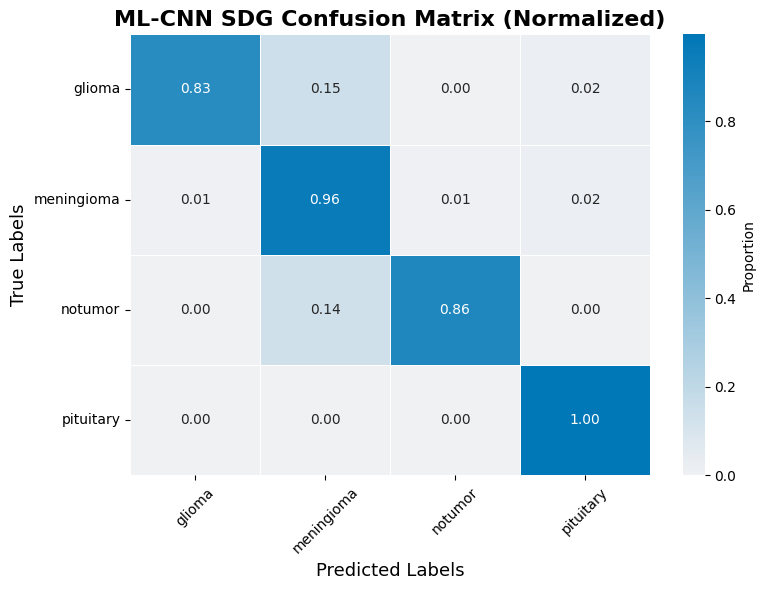

 Saved: ml_cnn sdg_confusion_matrix_gradient.png


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_gradient_confusion_matrix(y_true, y_pred, class_names, model_name="ML-CNN SDG"):
    cm = confusion_matrix(y_true, y_pred)
    cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize

    plt.figure(figsize=(8,6))
    cmap = sns.light_palette("#0077b6", as_cmap=True)  # ocean blue gradient
    sns.heatmap(cmn, annot=True, fmt=".2f", cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, cbar_kws={"label": "Proportion"})

    plt.title(f"{model_name} Confusion Matrix (Normalized)", fontsize=16, fontweight='bold')
    plt.xlabel("Predicted Labels", fontsize=13)
    plt.ylabel("True Labels", fontsize=13)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    filename = f"{model_name.lower().replace('-','_')}_confusion_matrix_gradient.png"
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    plt.show()
    print(f" Saved: {filename}")
plot_gradient_confusion_matrix(y_test_enc, y_pred, class_names, model_name="ML-CNN SDG")    

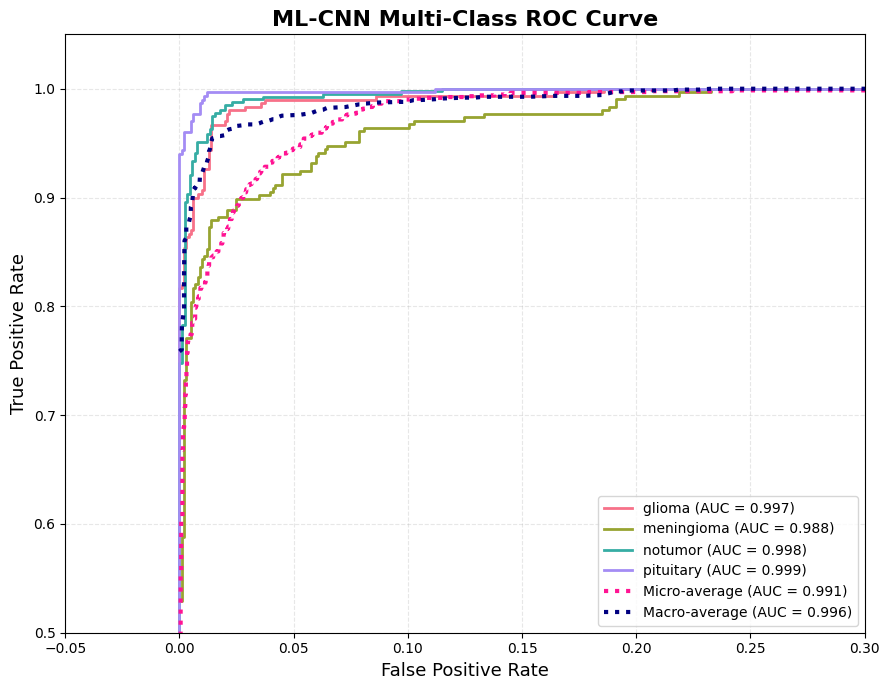

✅ Saved: ml_cnn_multiclass_roc.png


In [50]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_multiclass_roc(y_true, y_pred_probs, class_names, model_name="ML-CNN"):
    # Binarize true labels for multi-class ROC
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = y_true_bin.shape[1]

    # Compute ROC curve and AUC for each class
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Compute macro-average ROC curve and AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # ==== PLOT ====
    plt.figure(figsize=(9,7))
    colors = sns.color_palette("husl", n_classes)
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")
    plt.plot(fpr["micro"], tpr["micro"],
             label=f"Micro-average (AUC = {roc_auc['micro']:.3f})",
             color="deeppink", linestyle=':', linewidth=3)
    plt.plot(fpr["macro"], tpr["macro"],
             label=f"Macro-average (AUC = {roc_auc['macro']:.3f})",
             color="navy", linestyle=':', linewidth=3)
    plt.plot([0,1], [0,1], 'k--', lw=1.2)
    plt.xlim([-0.05, 0.3])
    plt.ylim([0.5, 1.05])
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate", fontsize=13)
    plt.title(f"{model_name} Multi-Class ROC Curve", fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10, frameon=True)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    filename = f"{model_name.lower().replace('-','_')}_multiclass_roc.png"
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")
plot_multiclass_roc(y_test_enc, y_pred_probs, class_names, model_name="ML-CNN") 

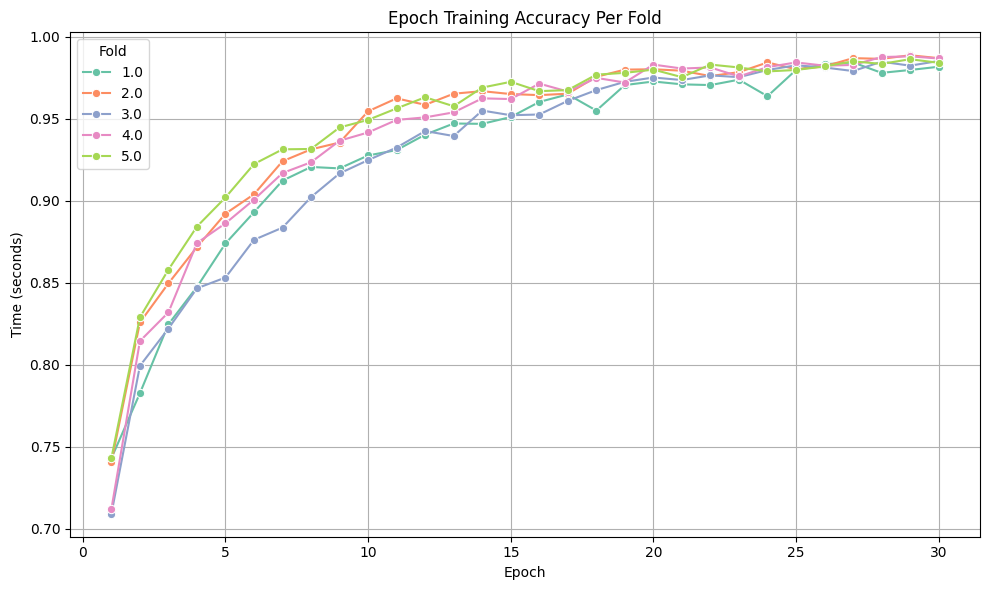

In [55]:
import pandas as pd 

df_time = pd.DataFrame(epoch_time_records, columns=["Fold", "Epoch", "Time", 
                           "Train_Loss", "Train_Acc", 
                           "Val_Loss", "Val_Acc"])
plt.figure(figsize=(10,6))
sns.lineplot(data=df_time, x='Epoch', y='Train_Acc', hue='Fold', marker='o', palette='Set2')
plt.title('Epoch Training Accuracy Per Fold')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_4930/2689546300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f'Fold {i+1}' for i in range(len(fold_accuracies))], y=fold_accuracies, palette='coolwarm')


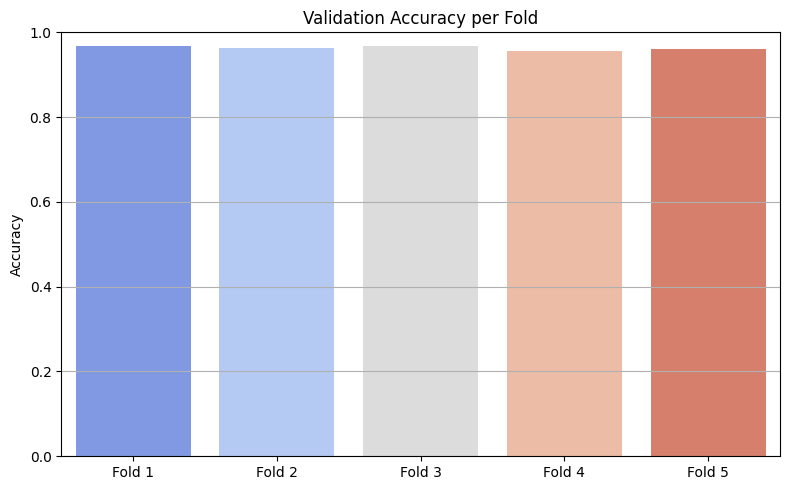

In [56]:
plt.figure(figsize=(8,5))
sns.barplot(x=[f'Fold {i+1}' for i in range(len(fold_accuracies))], y=fold_accuracies, palette='coolwarm')
plt.title('Validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.ylim(0.0, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


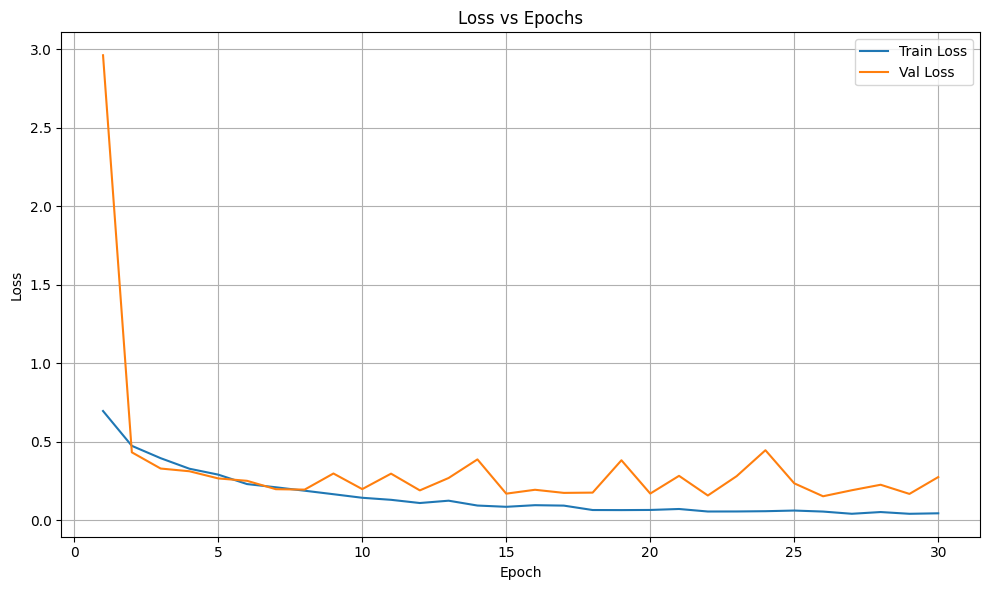

In [57]:
plt.figure(figsize=(10,6))
sns.lineplot(x=range(1, len(history.history['loss'])+1), y=history.history['loss'], label='Train Loss')
sns.lineplot(x=range(1, len(history.history['val_loss'])+1), y=history.history['val_loss'], label='Val Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


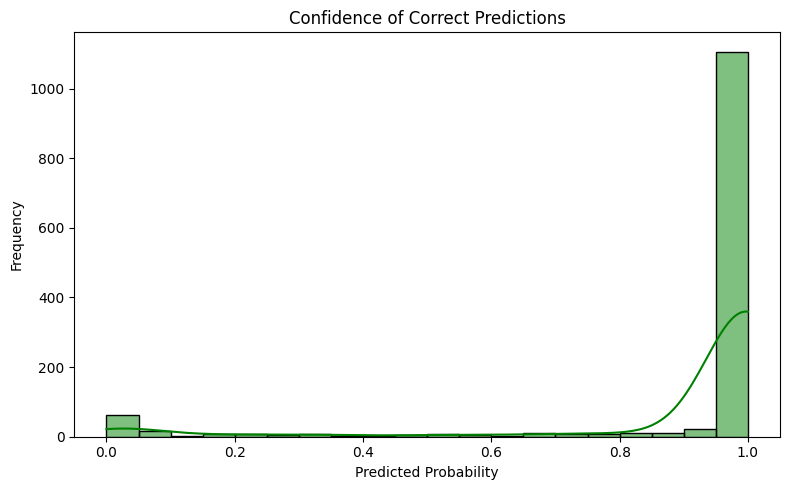

In [58]:
correct_probs = [y_pred_probs[i][y_test_enc[i]] for i in range(len(y_test_enc))]
plt.figure(figsize=(8,5))
sns.histplot(correct_probs, bins=20, kde=True, color='green')
plt.title('Confidence of Correct Predictions')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
